# Zadanie – Big Data Processing
## Detekcia porúch meračov pomocou Apache Spark

## 1. Inicializácia Spark a importy

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType,
    DoubleType, TimestampType, ArrayType, LongType
)
from pyspark.sql.window import Window

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    VectorAssembler, StandardScaler, StringIndexer, ChiSqSelector
)
from pyspark.ml.classification import (
    RandomForestClassifier, GBTClassifier, LogisticRegression,
    DecisionTreeClassifier, LinearSVC, OneVsRest
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator
)
from pyspark.mllib.evaluation import MulticlassMetrics, BinaryClassificationMetrics
from pyspark.ml.stat import Correlation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
# Inicializácia Spark session
spark = SparkSession.builder \
    .appName("FaultDetection") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .config("spark.sql.shuffle.partitions", "50") \
    .config("spark.sql.parquet.int96RebaseModeInRead", "CORRECTED") \
    .config("spark.sql.parquet.datetimeRebaseModeInRead", "CORRECTED") \
    .config("spark.sql.legacy.parquet.nanosAsLong", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark verzia:", spark.version)

Spark verzia: 4.0.0-preview2


In [3]:
priebehy_df = spark.read.parquet("./priebehy.parquet")

# Ak je timestamp načítaný ako Long (nanosekundy od epochy) → prevedieme na Timestamp
from pyspark.sql.types import LongType
ts_col_type = dict(priebehy_df.dtypes).get("timestamp")
if ts_col_type == "bigint":
    priebehy_df = priebehy_df.withColumn(
        "timestamp",
        (F.col("timestamp") / 1_000_000_000).cast(TimestampType())
    )

## 2. Načítanie dát

In [4]:
# ── Načítanie prúdov a napätí z Parquet ──────────────────────────────────────
# Predpokladaná schéma: eic (string), timestamp (timestamp),
# I_L1, I_L2, I_L3 (prúdy A), U_L1, U_L2, U_L3 (napätia V)
PRIEBEHY_PATH = "priebehy.parquet"

priebehy_df = spark.read.parquet(PRIEBEHY_PATH)

print("Schéma prúdov/napätí:")
priebehy_df.printSchema()
print(f"Počet záznamov: {priebehy_df.count():,}")
priebehy_df.show(5, truncate=False)

Schéma prúdov/napätí:
root
 |-- t_utc: long (nullable = true)
 |-- u2_norm: double (nullable = true)
 |-- i3_norm: double (nullable = true)
 |-- i2_norm: double (nullable = true)
 |-- i1_norm: double (nullable = true)
 |-- u1_norm: double (nullable = true)
 |-- u3_norm: double (nullable = true)
 |-- eic: string (nullable = true)
 |-- elektromer: double (nullable = true)

Počet záznamov: 7,659,371
+-------------------+-------+-------+-------+-------+-------+-------+----------------+----------+
|t_utc              |u2_norm|i3_norm|i2_norm|i1_norm|u1_norm|u3_norm|eic             |elektromer|
+-------------------+-------+-------+-------+-------+-------+-------+----------------+----------+
|1671232200000000000|14123.0|0.0    |0.0    |0.0    |12703.0|12814.0|24ZVS0000003196R|3052653.0 |
|1671232800000000000|14068.0|0.0    |0.0    |0.0    |12658.0|12747.0|24ZVS0000003196R|3052653.0 |
|1671233400000000000|14087.0|0.0    |0.0    |0.0    |12634.0|12758.0|24ZVS0000003196R|3052653.0 |
|16712340000

In [5]:
# ── Načítanie evidencie porúch z Excel (cez Pandas → Spark) ──────────────────
import openpyxl

wb = openpyxl.load_workbook("Poruchy.xlsx", read_only=True, data_only=True)
ws = wb["Evidencia poruch"]

rows = []
last_eic = None
last_start = None
last_end = None

for row in ws.iter_rows(min_row=2, values_only=True):
    eic, start, end, fault_type = row

    # Riadky bez EIC sú pokračovaním predchádzajúceho záznamu (viacero typov porúch)
    if eic is not None and str(eic).strip() != "":
        last_eic = str(eic).strip()
        last_start = start
        last_end = end
    else:
        # Zdieľa EIC (a príp. dátumy) z predchádzajúceho riadku
        if start is not None:
            last_start = start
        if end is not None:
            last_end = end

    if fault_type is not None and last_eic is not None:
        rows.append((last_eic, last_start, last_end, int(fault_type)))

wb.close()

# Konverzia Excel sériových čísel na dátumy
# Excel epoch: 1899-12-30 (Windows mode)
from datetime import date, timedelta
EXCEL_EPOCH = date(1899, 12, 30)

from datetime import date, timedelta, datetime

def excel_serial_to_date(serial):
    if serial is None:
        return None
    # openpyxl uz vracia datetime objekt priamo
    if isinstance(serial, (datetime, date)):
        return serial.date().isoformat() if isinstance(serial, datetime) else serial.isoformat()
    # záložný prípad: Excel sériové číslo (int/float)
    return (date(1899, 12, 30) + timedelta(days=int(serial))).isoformat()
    
rows_converted = [
    (eic, excel_serial_to_date(s), excel_serial_to_date(e), ft)
    for eic, s, e, ft in rows
]

poruchy_schema = StructType([
    StructField("eic", StringType(), True),
    StructField("datum_vzniku", StringType(), True),
    StructField("datum_ukoncenia", StringType(), True),
    StructField("typ_poruchy", IntegerType(), False),
])

poruchy_pd = pd.DataFrame(rows_converted, columns=["eic","datum_vzniku","datum_ukoncenia","typ_poruchy"])
poruchy_df = spark.createDataFrame(poruchy_pd, schema=poruchy_schema)

# Konverzia string → date
poruchy_df = (poruchy_df
    .withColumn("datum_vzniku",    F.to_date("datum_vzniku",    "yyyy-MM-dd"))
    .withColumn("datum_ukoncenia", F.to_date("datum_ukoncenia", "yyyy-MM-dd"))
)

print("Schéma porúch:")
poruchy_df.printSchema()
print(f"Počet záznamov porúch: {poruchy_df.count()}")
poruchy_df.show(10, truncate=False)

Schéma porúch:
root
 |-- eic: string (nullable = true)
 |-- datum_vzniku: date (nullable = true)
 |-- datum_ukoncenia: date (nullable = true)
 |-- typ_poruchy: integer (nullable = false)

Počet záznamov porúch: 147
+----------------+------------+---------------+-----------+
|eic             |datum_vzniku|datum_ukoncenia|typ_poruchy|
+----------------+------------+---------------+-----------+
|24ZVS0000003196R|2023-01-17  |2023-06-07     |4          |
|24ZVS0000001976B|2022-12-23  |2023-03-14     |5          |
|24ZVS0000002341C|2023-01-26  |2024-07-25     |4          |
|24ZVS0000002341C|2023-01-26  |2024-07-25     |6          |
|24ZVS0000003211K|NULL        |2023-10-23     |3          |
|24ZVS0000639518F|2023-03-19  |2024-08-22     |3          |
|24ZVS0000038467G|NULL        |2023-06-27     |1          |
|24ZVS0000038467G|NULL        |2023-06-27     |2          |
|24ZVS0000074609I|NULL        |2023-06-24     |1          |
|24ZVS0000002475S|2023-09-05  |2023-09-08     |4          |
+----

In [6]:
# ── Referenčná tabuľka typov porúch ─────────────────────────────────────────
fault_names = {
    1: "Chybný PTP L1",    2: "Chybný PTP L2",    3: "Chybný PTP L3",
    4: "Výpadok U L1",     5: "Výpadok U L2",     6: "Výpadok U L3",
    7: "Porucha P34 L1",   8: "Porucha P34 L2",   9: "Porucha P34 L3",
    13: "Vykratený I L1", 14: "Vykratený I L2",  15: "Vykratený I L3",
}
print("Typy porúch:", fault_names)

# Unikátne typy porúch v datasete
poruchy_df.groupBy("typ_poruchy").count().orderBy("typ_poruchy").show()

Typy porúch: {1: 'Chybný PTP L1', 2: 'Chybný PTP L2', 3: 'Chybný PTP L3', 4: 'Výpadok U L1', 5: 'Výpadok U L2', 6: 'Výpadok U L3', 7: 'Porucha P34 L1', 8: 'Porucha P34 L2', 9: 'Porucha P34 L3', 13: 'Vykratený I L1', 14: 'Vykratený I L2', 15: 'Vykratený I L3'}
+-----------+-----+
|typ_poruchy|count|
+-----------+-----+
|          1|   16|
|          2|   12|
|          3|   20|
|          4|   27|
|          5|   32|
|          6|   19|
|          7|    8|
|          8|    6|
|          9|    5|
|         13|    2|
+-----------+-----+



## 3. Integrácia dát

In [7]:
MERANIE_COLS = ["i1_norm", "i2_norm", "i3_norm", "u1_norm", "u2_norm", "u3_norm"]

# t_utc (nanosekundy) → timestamp → datum
priebehy_df = priebehy_df.withColumn(
    "timestamp",
    (F.col("t_utc") / 1_000_000_000).cast(TimestampType())
)
priebehy_df = priebehy_df.withColumn("datum", F.to_date("timestamp"))

# Náhradné dátumy pre NULL hodnoty v poruchy
poruchy_with_defaults = (poruchy_df
    .withColumn("datum_vzniku_safe",
        F.coalesce(F.col("datum_vzniku"), F.to_date(F.lit("2000-01-01"))))
    .withColumn("datum_ukoncenia_safe",
        F.coalesce(F.col("datum_ukoncenia"), F.to_date(F.lit("2099-12-31"))))
)

# ── Krok 1: Left join len na EIC (jednoduchý equi-join – spoľahlivý v každej verzii Spark)
# Každé meranie sa zreplikuje pre každú poruchu daného EIC
joined = (priebehy_df
    .join(F.broadcast(poruchy_with_defaults), on="eic", how="left")
)

# ── Krok 2: Typ poruchy nastavíme na NULL ak dátum merania nespadá do intervalu poruchy
joined = joined.withColumn(
    "typ_poruchy",
    F.when(
        (F.col("datum") >= F.col("datum_vzniku_safe")) &
        (F.col("datum") <= F.col("datum_ukoncenia_safe")),
        F.col("typ_poruchy")
    ).otherwise(F.lit(None).cast(IntegerType()))
)

# ── Krok 3: Agregácia späť na úroveň merania – zbierame aktívne typy porúch
# (collect_set ignoruje NULL → záznamy bez poruchy dostanú prázdne pole)
integrated_df = (joined
    .groupBy([c for c in priebehy_df.columns])
    .agg(F.collect_set("typ_poruchy").alias("typy_poruch"))
    .withColumn("ma_poruchu",
        F.when(F.size("typy_poruch") > 0, 1).otherwise(0).cast(IntegerType()))
)

print("Schéma po integrácii:")
integrated_df.printSchema()

Schéma po integrácii:
root
 |-- t_utc: long (nullable = true)
 |-- u2_norm: double (nullable = true)
 |-- i3_norm: double (nullable = true)
 |-- i2_norm: double (nullable = true)
 |-- i1_norm: double (nullable = true)
 |-- u1_norm: double (nullable = true)
 |-- u3_norm: double (nullable = true)
 |-- eic: string (nullable = true)
 |-- elektromer: double (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- datum: date (nullable = true)
 |-- typy_poruch: array (nullable = false)
 |    |-- element: integer (containsNull = false)
 |-- ma_poruchu: integer (nullable = false)



In [8]:
# Integrácia je dokončená v predchádzajúcej bunke
# Overenie rozloženia cieľového atribútu

print(f"Počet záznamov po integrácii: {integrated_df.count():,}")
print("Rozloženie cieľového atribútu 'ma_poruchu':")
integrated_df.groupBy("ma_poruchu").count().orderBy("ma_poruchu").show()

print("Ukážka záznamov s poruchou:")
integrated_df.filter(F.size("typy_poruch") > 0).show(5, truncate=False)

Počet záznamov po integrácii: 7,659,371
Rozloženie cieľového atribútu 'ma_poruchu':
+----------+-------+
|ma_poruchu|  count|
+----------+-------+
|         0|3206480|
|         1|4452891|
+----------+-------+

Ukážka záznamov s poruchou:
+-------------------+-------+-------+------------------+------------------+-------+-------+----------------+-----------+-------------------+----------+-----------+----------+
|t_utc              |u2_norm|i3_norm|i2_norm           |i1_norm           |u1_norm|u3_norm|eic             |elektromer |timestamp          |datum     |typy_poruch|ma_poruchu|
+-------------------+-------+-------+------------------+------------------+-------+-------+----------------+-----------+-------------------+----------+-----------+----------+
|1618870200000000000|233.0  |0.0    |0.0               |0.0               |232.0  |232.0  |24ZVS0000755803H|1.186934E7 |2021-04-19 22:10:00|2021-04-19|[2]        |1         |
|1618870200000000000|237.0  |0.0    |0.6000000000000001|0.0  

In [9]:
# ── Stratifikovaná vzorka 10 % ───────────────────────────────────────────────
# Zachovávame rozloženie cieľového atribútu (ma_poruchu)
fractions = (integrated_df
    .select("ma_poruchu")
    .distinct()
    .rdd
    .map(lambda r: (r[0], 0.10))
    .collectAsMap()
)

sampled_df = integrated_df.stat.sampleBy("ma_poruchu", fractions=fractions, seed=42)
sampled_df = sampled_df.cache()

print(f"Veľkosť vzorky: {sampled_df.count():,}")
print("Rozloženie vo vzorke:")
sampled_df.groupBy("ma_poruchu").count().orderBy("ma_poruchu").show()

Veľkosť vzorky: 766,908
Rozloženie vo vzorke:
+----------+------+
|ma_poruchu| count|
+----------+------+
|         0|320628|
|         1|446280|
+----------+------+



## Debugging cell - to be deleted

In [23]:
# ── DIAGNOSTIKA JOINU ────────────────────────────────────────────────────────

# 1. Rozsah dátumov v priebehy
print("Rozsah dátumov v priebehy:")
priebehy_df.select(F.min("datum"), F.max("datum")).show()

# 2. Rozsah dátumov v poruchy
print("Rozsah dátumov v poruchy:")
poruchy_df.select(
    F.min("datum_vzniku"), F.max("datum_vzniku"),
    F.min("datum_ukoncenia"), F.max("datum_ukoncenia")
).show()

# 3. Prekryv EIC kódov
priebehy_eics = set(priebehy_df.select("eic").distinct().rdd.flatMap(lambda x: x).collect())
poruchy_eics  = set(poruchy_df.select("eic").distinct().rdd.flatMap(lambda x: x).collect())
overlap = priebehy_eics & poruchy_eics
print(f"EIC v priebehy:  {len(priebehy_eics)}")
print(f"EIC v poruchy:   {len(poruchy_eics)}")
print(f"Spoločné EIC:    {len(overlap)}")
print(f"Príklad spoločných: {list(overlap)[:5]}")

# 4. Ručný test – vezmeme prvý spoločný EIC a skontrolujeme dátumové prekrytie
if overlap:
    test_eic = list(overlap)[0]
    print(f"\nTest pre EIC: {test_eic}")
    
    print("  Poruchy:")
    poruchy_df.filter(F.col("eic") == test_eic).show(truncate=False)
    
    print("  Merania (prvých 5):")
    priebehy_df.filter(F.col("eic") == test_eic).select("eic", "datum").show(5)
    
    print("  Merania v rozsahu poruchy:")
    fault_row = poruchy_df.filter(F.col("eic") == test_eic).first()
    priebehy_df.filter(
        (F.col("eic") == test_eic) &
        (F.col("datum") >= fault_row["datum_vzniku"]) &
        (F.col("datum") <= fault_row["datum_ukoncenia"])
    ).select("eic", "datum").show(5)

Rozsah dátumov v priebehy:
+----------+----------+
|min(datum)|max(datum)|
+----------+----------+
|2021-04-19|2025-08-05|
+----------+----------+

Rozsah dátumov v poruchy:
+-----------------+-----------------+--------------------+--------------------+
|min(datum_vzniku)|max(datum_vzniku)|min(datum_ukoncenia)|max(datum_ukoncenia)|
+-----------------+-----------------+--------------------+--------------------+
|       2021-05-20|       2025-01-30|          2023-01-13|          2025-02-06|
+-----------------+-----------------+--------------------+--------------------+

EIC v priebehy:  106
EIC v poruchy:   106
Spoločné EIC:    106
Príklad spoločných: ['24ZVS0000000612H', '24ZVS00000403133', '24ZVS0000001976B', '24ZVS0000069029H', '24ZVS0000002392W']

Test pre EIC: 24ZVS0000000612H
  Poruchy:
+----------------+------------+---------------+-----------+
|eic             |datum_vzniku|datum_ukoncenia|typ_poruchy|
+----------------+------------+---------------+-----------+
|24ZVS0000000612H|

## 4. Predspracovanie a transformácia

### 4.1 Identifikácia chýbajúcich hodnôt

In [10]:
# Numerické stĺpce merania (prúdy a napätia)
MERANIE_COLS = ["i1_norm", "i2_norm", "i3_norm", "u1_norm", "u2_norm", "u3_norm"]

# Počet a podiel chýbajúcich hodnôt v každom stĺpci
total = sampled_df.count()
missing_counts = sampled_df.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in MERANIE_COLS
]).collect()[0].asDict()

print("Chýbajúce hodnoty:")
print(f"{'Stĺpec':<12} {'Chýba':>8} {'Podiel':>10}")
print("-" * 32)
for col_name, cnt in missing_counts.items():
    print(f"{col_name:<12} {cnt:>8} {cnt/total*100:>9.2f}%")

Chýbajúce hodnoty:
Stĺpec          Chýba     Podiel
--------------------------------
i1_norm          7687      1.00%
i2_norm          7684      1.00%
i3_norm          7687      1.00%
u1_norm          7687      1.00%
u2_norm          7684      1.00%
u3_norm          7687      1.00%


In [11]:
# Nahradenie chýbajúcich hodnôt mediánom (robustnejší ako priemer pri outlieroch)
# Vypočítame mediány na trénovacej časti (pred splitom) – tu ešte na celej vzorke
medians = {}
for c in MERANIE_COLS:
    median_val = sampled_df.approxQuantile(c, [0.5], 0.001)[0]
    medians[c] = median_val

print("Mediány (použijú sa pre imputáciu):")
for c, v in medians.items():
    print(f"  {c}: {v:.4f}")

# Nahradenie null hodnôt mediánom
sampled_df = sampled_df.fillna(medians)
print("\nChýbajúce hodnoty po nahradení:")
sampled_df.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in MERANIE_COLS
]).show()

Mediány (použijú sa pre imputáciu):
  i1_norm: 2.6000
  i2_norm: 3.2000
  i3_norm: 2.4000
  u1_norm: 238.7400
  u2_norm: 238.7300
  u3_norm: 239.0000

Chýbajúce hodnoty po nahradení:
+-------+-------+-------+-------+-------+-------+
|i1_norm|i2_norm|i3_norm|u1_norm|u2_norm|u3_norm|
+-------+-------+-------+-------+-------+-------+
|      0|      0|      0|      0|      0|      0|
+-------+-------+-------+-------+-------+-------+



### 4.2 Identifikácia a spracovanie outlierov

In [12]:
# Detekcia outlierov metódou IQR (medzikvartilové rozpätie)
# Záznamy mimo [Q1 - 1.5*IQR, Q3 + 1.5*IQR] sú považované za outliery

quantiles = sampled_df.approxQuantile(MERANIE_COLS, [0.25, 0.75], 0.01)

iqr_bounds = {}
for i, c in enumerate(MERANIE_COLS):
    q1, q3 = quantiles[i]
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    iqr_bounds[c] = (lower, upper)
    print(f"{c}: Q1={q1:.3f}, Q3={q3:.3f}, IQR={iqr:.3f} → [{lower:.3f}, {upper:.3f}]")

i1_norm: Q1=0.000, Q3=10.120, IQR=10.120 → [-15.180, 25.300]
i2_norm: Q1=0.200, Q3=10.000, IQR=9.800 → [-14.500, 24.700]
i3_norm: Q1=0.000, Q3=9.750, IQR=9.750 → [-14.625, 24.375]
u1_norm: Q1=236.220, Q3=241.000, IQR=4.780 → [229.050, 248.170]
u2_norm: Q1=236.210, Q3=241.000, IQR=4.790 → [229.025, 248.185]
u3_norm: Q1=236.620, Q3=241.000, IQR=4.380 → [230.050, 247.570]


In [13]:
# Počet outlierov v každom stĺpci
print("\nPočet outlierov (mimo IQR*1.5):")
for c, (lo, hi) in iqr_bounds.items():
    n_out = sampled_df.filter((F.col(c) < lo) | (F.col(c) > hi)).count()
    print(f"  {c}: {n_out} ({n_out/total*100:.2f}%)")

# Spracovanie: orezanie (clipping) na hranice IQR – zachováme záznamy, ale
# ohraničíme extrémne hodnoty. Toto je vhodné pre merania (porucha merania
# vs. fyzikálna anomália).
for c, (lo, hi) in iqr_bounds.items():
    sampled_df = sampled_df.withColumn(
        c,
        F.when(F.col(c) < lo, lo)
         .when(F.col(c) > hi, hi)
         .otherwise(F.col(c))
    )

print("\nOutliery boli orezané (clipping) na hranice IQR.")


Počet outlierov (mimo IQR*1.5):
  i1_norm: 80222 (10.46%)
  i2_norm: 86362 (11.26%)
  i3_norm: 98470 (12.84%)
  u1_norm: 93316 (12.17%)
  u2_norm: 90032 (11.74%)
  u3_norm: 101255 (13.20%)

Outliery boli orezané (clipping) na hranice IQR.


### 4.3 Popisné charakteristiky

In [14]:
# Základné štatistiky pre numerické stĺpce
print("=== Popisné charakteristiky (vzorka) ===")
sampled_df.select(MERANIE_COLS).describe().show()

# Šikmosť a špicatosť (Spark nemá priamu funkciu, počítame cez momentá)
print("\nŠikmosť (skewness) a špicatosť (kurtosis):")
stats = sampled_df.select([
    F.skewness(c).alias(f"skew_{c}") for c in MERANIE_COLS
] + [
    F.kurtosis(c).alias(f"kurt_{c}") for c in MERANIE_COLS
]).collect()[0].asDict()

print(f"{'Stĺpec':<12} {'Šikmosť':>12} {'Špicatosť':>12}")
print("-" * 38)
for c in MERANIE_COLS:
    print(f"{c:<12} {stats[f'skew_{c}']:>12.4f} {stats[f'kurt_{c}']:>12.4f}")

=== Popisné charakteristiky (vzorka) ===
+-------+------------------+------------------+-----------------+------------------+------------------+------------------+
|summary|           i1_norm|           i2_norm|          i3_norm|           u1_norm|           u2_norm|           u3_norm|
+-------+------------------+------------------+-----------------+------------------+------------------+------------------+
|  count|            766908|            766908|           766908|            766908|            766908|            766908|
|   mean| 6.762343890662577| 6.878504831739639|6.646092936180027| 238.9226576720974| 239.0329809964175|239.09819850619704|
| stddev| 8.597053415717689| 8.313784588176807|8.546092710414742| 4.499584722702466| 4.466108609738601|4.2596093661273295|
|    min|               0.0|               0.0|              0.0|            229.05|229.02500000000003|            230.05|
|    max|25.300000000000004|24.700000000000003|           24.375|248.17000000000002|           248

### 4.4 Transformácia na denné priebehy

## Cache diagnosis - to be deleted

In [19]:
# Uvoľnenie starého cache pred rerunnutím
try:
    daily_df.unpersist()
    print("Cache uvoľnený.")
except:
    print("daily_df ešte neexistoval.")

# Rýchla kontrola - typy_poruch v sampled_df pred agregáciou
print("\nUkážka typy_poruch v sampled_df (len poruchy):")
sampled_df.filter(F.size("typy_poruch") > 0).select("eic", "datum", "typy_poruch").show(5, truncate=False)

print("Počet záznamov s neprázdnym typy_poruch:")
sampled_df.filter(F.size("typy_poruch") > 0).count()

Cache uvoľnený.

Ukážka typy_poruch v sampled_df (len poruchy):
+----------------+----------+-----------+
|eic             |datum     |typy_poruch|
+----------------+----------+-----------+
|24ZVS0000079910X|2021-04-20|[2]        |
|24ZVS0000003680M|2021-04-20|[1]        |
|24ZVS0000001760Y|2021-04-20|[1]        |
|24ZVS00000723611|2021-04-20|[3]        |
|24ZVS0000658596P|2021-04-20|[3]        |
+----------------+----------+-----------+
only showing top 5 rows

Počet záznamov s neprázdnym typy_poruch:


446280

In [22]:
# Pre každé (eic, dátum) vypočítame agregované štatistiky
# Cieľový atribút (ma_poruchu): ak v daný deň nastala AKÁKOĽVEK porucha → 1
# Typy porúch dňa: zjednotenie všetkých aktívnych typov

# Definícia agregácií pre každý meraný stĺpec
agg_exprs = []
for c in MERANIE_COLS:
    agg_exprs += [
        F.mean(c).alias(f"{c}_mean"),
        F.max(c).alias(f"{c}_max"),
        F.min(c).alias(f"{c}_min"),
        F.skewness(c).alias(f"{c}_skew"),
        F.kurtosis(c).alias(f"{c}_kurt"),
    ]

# Cieľové stĺpce
agg_exprs += [
    F.max("ma_poruchu").alias("ma_poruchu"),          # 1 ak aspoň raz porucha v daný deň
    F.array_distinct(
        F.flatten(F.collect_list("typy_poruch"))
    ).alias("typy_poruch_den"),
]

daily_df = (sampled_df
    .groupBy("eic", "datum")
    .agg(*agg_exprs)
    # Deduplikácia typov porúch v daný deň
    .withColumn("typy_poruch_den", F.array_distinct("typy_poruch_den"))
)

daily_df = daily_df.cache()

# Poznámka: NULL hodnoty v skewness/kurtosis vznikajú pri denných priebehy
# kde sú všetky merania konštantné (napr. odpojený merač).
# Tieto príznaky neboli vybrané pri selekcii atribútov, preto neovplyvňujú modely.
# VectorAssembler s handleInvalid='skip' by ich vylúčil aj keby boli zahrnuté.
print(f"Počet denných priebehov: {daily_df.count():,}")
print("\nSchéma denných priebehov:")
daily_df.printSchema()
daily_df.show(5, truncate=False)

Počet denných priebehov: 52,618

Schéma denných priebehov:
root
 |-- eic: string (nullable = true)
 |-- datum: date (nullable = true)
 |-- i1_norm_mean: double (nullable = true)
 |-- i1_norm_max: double (nullable = true)
 |-- i1_norm_min: double (nullable = true)
 |-- i1_norm_skew: double (nullable = true)
 |-- i1_norm_kurt: double (nullable = true)
 |-- i2_norm_mean: double (nullable = true)
 |-- i2_norm_max: double (nullable = true)
 |-- i2_norm_min: double (nullable = true)
 |-- i2_norm_skew: double (nullable = true)
 |-- i2_norm_kurt: double (nullable = true)
 |-- i3_norm_mean: double (nullable = true)
 |-- i3_norm_max: double (nullable = true)
 |-- i3_norm_min: double (nullable = true)
 |-- i3_norm_skew: double (nullable = true)
 |-- i3_norm_kurt: double (nullable = true)
 |-- u1_norm_mean: double (nullable = true)
 |-- u1_norm_max: double (nullable = true)
 |-- u1_norm_min: double (nullable = true)
 |-- u1_norm_skew: double (nullable = true)
 |-- u1_norm_kurt: double (nullable = 

In [23]:
# Rozloženie cieľového atribútu v denných priebehy
print("Rozloženie 'ma_poruchu' v denných priebehy:")
daily_df.groupBy("ma_poruchu").count().orderBy("ma_poruchu").show()

print("\nNajčastejšie kombinácie typov porúch:")
(daily_df
    .filter(F.size("typy_poruch_den") > 0)
    .groupBy("typy_poruch_den")
    .count()
    .orderBy(F.desc("count"))
    .show(15, truncate=False)
)

Rozloženie 'ma_poruchu' v denných priebehy:
+----------+-----+
|ma_poruchu|count|
+----------+-----+
|         0|21673|
|         1|30945|
+----------+-----+


Najčastejšie kombinácie typov porúch:
+---------------+-----+
|typy_poruch_den|count|
+---------------+-----+
|[3]            |9212 |
|[1]            |7717 |
|[2]            |3729 |
|[1, 2, 3]      |1853 |
|[8]            |1355 |
|[1, 2]         |1251 |
|[7]            |1209 |
|[4, 6]         |870  |
|[4]            |608  |
|[9]            |573  |
|[5, 6]         |482  |
|[4, 5]         |472  |
|[5]            |455  |
|[2, 3]         |351  |
|[7, 8, 9]      |341  |
+---------------+-----+
only showing top 15 rows



### 4.5 Vytvorenie príznakov pre multi-label klasifikáciu

In [24]:
# Každý typ poruchy dostane vlastný binárny stĺpec (multi-label prístup)
# Typy porúch prítomné v datasete
present_fault_types = (poruchy_df
    .select("typ_poruchy")
    .distinct()
    .rdd.map(lambda r: r[0])
    .collect()
)
present_fault_types = sorted([t for t in present_fault_types if t is not None])
print("Typy porúch v datasete:", present_fault_types)

# Pridanie binárnych stĺpcov pre každý typ
for ft in present_fault_types:
    daily_df = daily_df.withColumn(
        f"porucha_{ft}",
        F.when(F.array_contains("typy_poruch_den", ft), 1).otherwise(0).cast(IntegerType())
    )

print("\nPočet záznamo so každým typom poruchy:")
daily_df.select([F.sum(f"porucha_{ft}").alias(f"typ_{ft}") for ft in present_fault_types]).show()

Typy porúch v datasete: [1, 2, 3, 4, 5, 6, 7, 8, 9, 13]

Počet záznamo so každým typom poruchy:
+-----+-----+-----+-----+-----+-----+-----+-----+-----+------+
|typ_1|typ_2|typ_3|typ_4|typ_5|typ_6|typ_7|typ_8|typ_9|typ_13|
+-----+-----+-----+-----+-----+-----+-----+-----+-----+------+
|10821| 7184|11416| 1967| 1426| 1589| 1550| 1696|  914|   230|
+-----+-----+-----+-----+-----+-----+-----+-----+-----+------+



### 4.6 Rozdelenie na trénovaciu a testovaciu množinu

In [25]:
# Stratifikované rozdelenie 80/20 podľa cieľového atribútu (ma_poruchu)
# Zachovávame rozloženie tried

train_df, test_df = daily_df.randomSplit([0.8, 0.2], seed=42)
train_df = train_df.cache()
test_df  = test_df.cache()

print(f"Tréningová množina: {train_df.count():,} záznamov")
print(f"Testovacia množina:  {test_df.count():,} záznamov")

print("\nRozloženie tried - tréning:")
train_df.groupBy("ma_poruchu").count().orderBy("ma_poruchu").show()
print("Rozloženie tried - test:")
test_df.groupBy("ma_poruchu").count().orderBy("ma_poruchu").show()

Tréningová množina: 42,085 záznamov
Testovacia množina:  10,533 záznamov

Rozloženie tried - tréning:
+----------+-----+
|ma_poruchu|count|
+----------+-----+
|         0|17339|
|         1|24746|
+----------+-----+

Rozloženie tried - test:
+----------+-----+
|ma_poruchu|count|
+----------+-----+
|         0| 4334|
|         1| 6199|
+----------+-----+



### 4.7 Výpočet korelácií

Korelačná matica (rozmery): (30, 30)


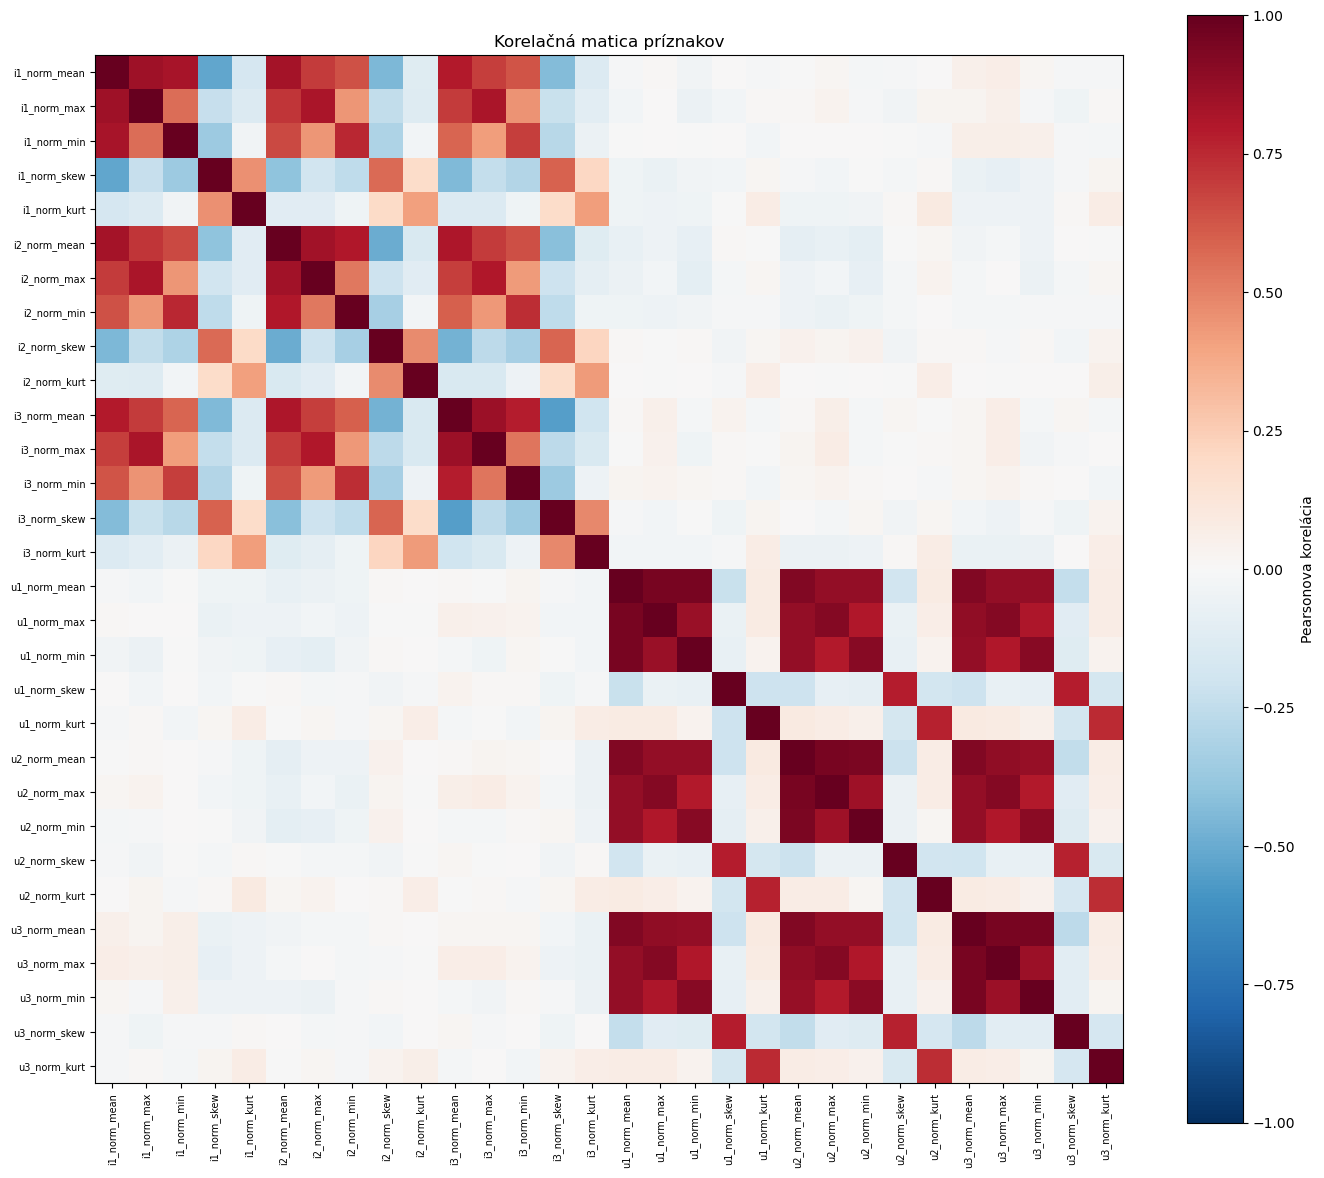

Korelačná matica uložená.


In [26]:
# Numerické príznaky (agregované štatistiky)
FEATURE_COLS = [f"{c}_{stat}" 
                for c in MERANIE_COLS 
                for stat in ["mean", "max", "min", "skew", "kurt"]]

# Zostavenie vektora pre korelačnú maticu
assembler_corr = VectorAssembler(inputCols=FEATURE_COLS, outputCol="features_corr",
                                  handleInvalid="skip")
train_vec = assembler_corr.transform(train_df.select(FEATURE_COLS + ["ma_poruchu"]))

# Pearsonova korelačná matica
corr_matrix = Correlation.corr(train_vec, "features_corr", method="pearson")
corr_array = corr_matrix.collect()[0][0].toArray()

print("Korelačná matica (rozmery):", corr_array.shape)

# Vizualizácia korelačnej matice
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_array, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label="Pearsonova korelácia")
ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_xticklabels(FEATURE_COLS, rotation=90, fontsize=7)
ax.set_yticklabels(FEATURE_COLS, fontsize=7)
ax.set_title("Korelačná matica príznakov")
plt.tight_layout()
plt.savefig("korelacna_matica.png", dpi=120, bbox_inches="tight")
plt.show()
print("Korelačná matica uložená.")

### 4.8 Dôležitosť atribútov a selekcia

Top 15 najdôležitejších príznakov:
     priznak  dolezitost
i2_norm_mean    0.264516
 i2_norm_max    0.174281
i3_norm_mean    0.120042
 i1_norm_max    0.092440
i1_norm_mean    0.083549
 i3_norm_max    0.068554
 i2_norm_min    0.042947
 i3_norm_min    0.033120
 u2_norm_max    0.022397
 i1_norm_min    0.020077
u2_norm_mean    0.013487
 u1_norm_max    0.009837
 u2_norm_min    0.008880
u3_norm_mean    0.008761
 u3_norm_max    0.008149


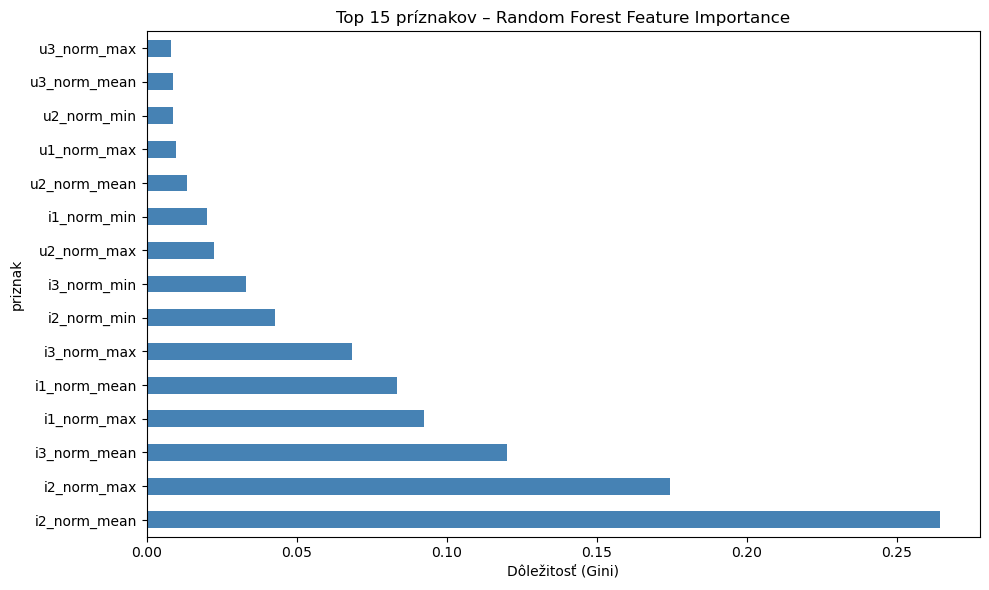

In [27]:
# Dôležitosť atribútov pomocou Random Forest (Gini impurity)
assembler_fi = VectorAssembler(inputCols=FEATURE_COLS, outputCol="features_fi",
                                handleInvalid="skip")
train_fi = assembler_fi.transform(train_df.select(FEATURE_COLS + ["ma_poruchu"]))
train_fi = train_fi.withColumn("label", F.col("ma_poruchu").cast(DoubleType()))

rf_fi = RandomForestClassifier(featuresCol="features_fi", labelCol="label",
                                numTrees=100, seed=42)
rf_fi_model = rf_fi.fit(train_fi)

importances = rf_fi_model.featureImportances.toArray()
fi_df = pd.DataFrame({"priznak": FEATURE_COLS, "dolezitost": importances})
fi_df = fi_df.sort_values("dolezitost", ascending=False)

print("Top 15 najdôležitejších príznakov:")
print(fi_df.head(15).to_string(index=False))

# Vizualizácia
fig, ax = plt.subplots(figsize=(10, 6))
fi_df.head(15).plot.barh(x="priznak", y="dolezitost", ax=ax, legend=False, color="steelblue")
ax.set_xlabel("Dôležitosť (Gini)")
ax.set_title("Top 15 príznakov – Random Forest Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

In [28]:
# Selekcia príznakov – ponecháme príznaky s dôležitosťou > prah
IMPORTANCE_THRESHOLD = 0.02
SELECTED_FEATURES = fi_df[fi_df["dolezitost"] > IMPORTANCE_THRESHOLD]["priznak"].tolist()

print(f"Vybraných príznakov (dôležitosť > {IMPORTANCE_THRESHOLD}): {len(SELECTED_FEATURES)}")
print(SELECTED_FEATURES)

Vybraných príznakov (dôležitosť > 0.02): 10
['i2_norm_mean', 'i2_norm_max', 'i3_norm_mean', 'i1_norm_max', 'i1_norm_mean', 'i3_norm_max', 'i2_norm_min', 'i3_norm_min', 'u2_norm_max', 'i1_norm_min']


## 5. Pomocné funkcie – vyhodnotenie modelov

In [31]:
def evaluate_binary(predictions_df, label_col="label", pred_col="prediction",
                    model_name="Model"):
    """Vyhodnotenie binárneho klasifikátora – kontigenčná tabuľka + metriky."""
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")

    pal = (predictions_df
           .select(pred_col, label_col)
           .rdd
           .map(lambda r: (float(r[0]), float(r[1]))))

    metrics = MulticlassMetrics(pal)

    # Kontigenčná tabuľka
    cm = metrics.confusionMatrix().toArray()
    print("\nKontingenčná tabuľka (riadky=skutočné, stĺpce=predikované):")
    print(f"  {'':>10} | {'Pred 0':>8} | {'Pred 1':>8}")
    print(f"  {'-'*32}")
    print(f"  {'Skut 0':>10} | {int(cm[0][0]):>8} | {int(cm[0][1]):>8}")
    print(f"  {'Skut 1':>10} | {int(cm[1][0]):>8} | {int(cm[1][1]):>8}")

    # Metriky
    precision = metrics.weightedPrecision
    recall    = metrics.weightedRecall
    f1        = metrics.weightedFMeasure()
    accuracy  = metrics.accuracy

    # MCC
    TP = cm[1][1]; TN = cm[0][0]; FP = cm[0][1]; FN = cm[1][0]
    denom = math.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
    mcc = ((TP*TN) - (FP*FN)) / denom if denom != 0 else 0.0

    print(f"\n  Presnosť  (Precision): {precision:.4f}")
    print(f"  Návratnosť (Recall):   {recall:.4f}")
    print(f"  F1 skóre:              {f1:.4f}")
    print(f"  Presnosť  (Accuracy):  {accuracy:.4f}")
    print(f"  MCC:                   {mcc:.4f}")

    return {"model": model_name, "precision": precision, "recall": recall,
            "f1": f1, "accuracy": accuracy, "mcc": mcc}


def evaluate_multiclass(predictions_df, label_col="label", pred_col="prediction",
                         model_name="Model"):
    """Vyhodnotenie multi-class klasifikátora."""
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")

    pal = (predictions_df
           .select(pred_col, label_col)
           .rdd
           .map(lambda r: (float(r[0]), float(r[1]))))

    metrics = MulticlassMetrics(pal)
    cm = metrics.confusionMatrix().toArray()

    print("\nKontingenčná tabuľka:")
    print(cm)

    precision = metrics.weightedPrecision
    recall    = metrics.weightedRecall
    f1        = metrics.weightedFMeasure()
    accuracy  = metrics.accuracy

    print(f"\n  Presnosť  (Precision): {precision:.4f}")
    print(f"  Návratnosť (Recall):   {recall:.4f}")
    print(f"  F1 skóre:              {f1:.4f}")
    print(f"  Presnosť  (Accuracy):  {accuracy:.4f}")
    print("  (MCC nie je štandardné pre viactriednu klasifikáciu)")

    return {"model": model_name, "precision": precision, "recall": recall,
            "f1": f1, "accuracy": accuracy, "mcc": None}

## 6. Binárna klasifikácia – detekcia poruchy (áno/nie)

In [32]:
# Príprava dát (tréning + test) pre binárny klasifikátor
assembler_bin = VectorAssembler(
    inputCols=SELECTED_FEATURES, outputCol="features", handleInvalid="skip"
)
scaler_bin = StandardScaler(inputCol="features", outputCol="features_scaled",
                             withStd=True, withMean=True)

train_bin = (train_df
    .withColumn("label", F.col("ma_poruchu").cast(DoubleType()))
    .select(SELECTED_FEATURES + ["label"])
)
test_bin = (test_df
    .withColumn("label", F.col("ma_poruchu").cast(DoubleType()))
    .select(SELECTED_FEATURES + ["label"])
)

print("Príznaky pre binárny klasifikátor:", SELECTED_FEATURES)
print(f"Tréning: {train_bin.count()}, Test: {test_bin.count()}")

results_binary = []

Príznaky pre binárny klasifikátor: ['i2_norm_mean', 'i2_norm_max', 'i3_norm_mean', 'i1_norm_max', 'i1_norm_mean', 'i3_norm_max', 'i2_norm_min', 'i3_norm_min', 'u2_norm_max', 'i1_norm_min']
Tréning: 42085, Test: 10533


### 6.1 Binárny klasifikátor – Logistická regresia

In [33]:
lr = LogisticRegression(featuresCol="features_scaled", labelCol="label",
                        maxIter=100, regParam=0.01, elasticNetParam=0.0)

pipeline_lr = Pipeline(stages=[assembler_bin, scaler_bin, lr])
lr_model = pipeline_lr.fit(train_bin)

pred_lr = lr_model.transform(test_bin)
res = evaluate_binary(pred_lr, model_name="Logistická regresia")
results_binary.append(res)


  Logistická regresia


/opt/conda/lib/python3.12/site-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(



Kontingenčná tabuľka (riadky=skutočné, stĺpce=predikované):
             |   Pred 0 |   Pred 1
  --------------------------------
      Skut 0 |     1933 |     2401
      Skut 1 |     1018 |     5181

  Presnosť  (Precision): 0.6717
  Návratnosť (Recall):   0.6754
  F1 skóre:              0.6609
  Presnosť  (Accuracy):  0.6754
  MCC:                   0.3088


### 6.2 Binárny klasifikátor – Random Forest

In [34]:
rf_bin = RandomForestClassifier(
    featuresCol="features", labelCol="label",
    numTrees=100, maxDepth=8, seed=42
)
pipeline_rf = Pipeline(stages=[assembler_bin, rf_bin])
rf_bin_model = pipeline_rf.fit(train_bin)

pred_rf = rf_bin_model.transform(test_bin)
res = evaluate_binary(pred_rf, model_name="Random Forest")
results_binary.append(res)


  Random Forest

Kontingenčná tabuľka (riadky=skutočné, stĺpce=predikované):
             |   Pred 0 |   Pred 1
  --------------------------------
      Skut 0 |     4139 |      195
      Skut 1 |      433 |     5766

  Presnosť  (Precision): 0.9418
  Návratnosť (Recall):   0.9404
  F1 skóre:              0.9406
  Presnosť  (Accuracy):  0.9404
  MCC:                   0.8788


### 6.3 Binárny klasifikátor – Gradient Boosted Trees (GBT)

In [35]:
gbt = GBTClassifier(
    featuresCol="features", labelCol="label",
    maxIter=50, maxDepth=5, seed=42
)
pipeline_gbt = Pipeline(stages=[assembler_bin, gbt])
gbt_model = pipeline_gbt.fit(train_bin)

pred_gbt = gbt_model.transform(test_bin)
res = evaluate_binary(pred_gbt, model_name="Gradient Boosted Trees")
results_binary.append(res)


  Gradient Boosted Trees

Kontingenčná tabuľka (riadky=skutočné, stĺpce=predikované):
             |   Pred 0 |   Pred 1
  --------------------------------
      Skut 0 |     4107 |      227
      Skut 1 |      385 |     5814

  Presnosť  (Precision): 0.9426
  Návratnosť (Recall):   0.9419
  F1 skóre:              0.9420
  Presnosť  (Accuracy):  0.9419
  MCC:                   0.8811


In [36]:
# Porovnanie binárnych klasifikátorov
print("\n=== Porovnanie binárnych klasifikátorov ===")
results_bin_df = pd.DataFrame(results_binary)
print(results_bin_df.to_string(index=False))

best_binary = results_bin_df.loc[results_bin_df["mcc"].idxmax(), "model"]
print(f"\n→ Najlepší binárny model podľa MCC: {best_binary}")


=== Porovnanie binárnych klasifikátorov ===
                 model  precision   recall       f1  accuracy      mcc
   Logistická regresia   0.671686 0.675401 0.660877  0.675401 0.308782
         Random Forest   0.941779 0.940378 0.940591  0.940378 0.878846
Gradient Boosted Trees   0.942619 0.941897 0.942042  0.941897 0.881105

→ Najlepší binárny model podľa MCC: Gradient Boosted Trees


## 7. Detekcia všetkých typov porúch (multi-class / multi-label)

In [37]:
# Stratégia: multi-label pomocou OneVsRest (jeden binárny klasifikátor per typ)
# Pre každý typ poruchy trénujeme samostatný binárny model.
# Alternatívne: multi-class klasifikácia s dominantným typom (jednoduchší prístup).

# ── Prístup A: Multi-class s dominantným typom poruchy ────────────────────────
# Záznamy bez poruchy → trieda 0
# Záznamy s jednou poruchou → jej typ
# Záznamy s viacerými poruchami → prvý typ (najnižší číselný kód)

daily_mc = (daily_df
    .withColumn("fault_class",
        F.when(F.size("typy_poruch_den") == 0, F.lit(0))
         .otherwise(F.array_min("typy_poruch_den"))
    )
    .withColumn("fault_class", F.col("fault_class").cast(DoubleType()))
)

print("Rozloženie tried (multi-class):")
daily_mc.groupBy("fault_class").count().orderBy("fault_class").show()

# Indexovanie tried na 0..N-1
fault_indexer = StringIndexer(
    inputCol="fault_class", outputCol="label_mc",
    handleInvalid="keep", stringOrderType="frequencyDesc"
)

train_mc = fault_indexer.fit(daily_mc).transform(
    daily_mc.filter(F.col("datum").isin(
        [r.datum for r in train_df.select("datum").collect()]
    ))
)
# Jednoduchší split – znova podľa náhodného rozdelenia
train_mc_base, test_mc_base = (daily_mc
    .select(SELECTED_FEATURES + ["fault_class"])
    .withColumn("fault_class", F.col("fault_class").cast(DoubleType()))
    .randomSplit([0.8, 0.2], seed=42)
)

assembler_mc = VectorAssembler(
    inputCols=SELECTED_FEATURES, outputCol="features", handleInvalid="skip"
)

results_multiclass = []

Rozloženie tried (multi-class):
+-----------+-----+
|fault_class|count|
+-----------+-----+
|        0.0|21673|
|        1.0|10821|
|        2.0| 4080|
|        3.0| 9212|
|        4.0| 1967|
|        5.0|  937|
|        6.0|  220|
|        7.0| 1550|
|        8.0| 1355|
|        9.0|  573|
|       13.0|  230|
+-----------+-----+



### 7.1 Multi-class – Random Forest

In [38]:
rf_mc = RandomForestClassifier(
    featuresCol="features", labelCol="fault_class",
    numTrees=100, maxDepth=8, seed=42
)
pipeline_rf_mc = Pipeline(stages=[assembler_mc, rf_mc])
rf_mc_model = pipeline_rf_mc.fit(train_mc_base)

pred_rf_mc = rf_mc_model.transform(test_mc_base)
res = evaluate_multiclass(pred_rf_mc, label_col="fault_class",
                           model_name="RF – Multi-class")
results_multiclass.append(res)


  RF – Multi-class


/opt/conda/lib/python3.12/site-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(



Kontingenčná tabuľka:
[[4.224e+03 2.200e+01 2.700e+01 2.600e+01 2.500e+01 1.300e+01 0.000e+00
  3.100e+01 2.000e+00 1.000e+00 0.000e+00]
 [6.300e+01 2.068e+03 1.000e+00 4.000e+00 0.000e+00 0.000e+00 0.000e+00
  4.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [5.100e+01 1.200e+01 7.630e+02 1.000e+00 1.000e+00 0.000e+00 0.000e+00
  3.000e+00 1.000e+00 0.000e+00 0.000e+00]
 [7.300e+01 0.000e+00 1.000e+00 1.770e+03 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 1.000e+00 0.000e+00]
 [2.650e+02 1.000e+00 5.000e+00 1.000e+01 7.000e+01 4.200e+01 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [5.100e+01 1.000e+00 0.000e+00 0.000e+00 4.000e+00 1.310e+02 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [4.500e+01 1.000e+00 1.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [2.600e+01 1.800e+01 2.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  2.460e+02 0.000e+00 0.000e+00 0.000e+00]
 [6.500e+01 9.000e+00 2.000e+00 0.000e+00 0.000e+00 0.000

### 7.2 Multi-class – Decision Tree

In [39]:
dt_mc = DecisionTreeClassifier(
    featuresCol="features", labelCol="fault_class",
    maxDepth=10, seed=42
)
pipeline_dt_mc = Pipeline(stages=[assembler_mc, dt_mc])
dt_mc_model = pipeline_dt_mc.fit(train_mc_base)

pred_dt_mc = dt_mc_model.transform(test_mc_base)
res = evaluate_multiclass(pred_dt_mc, label_col="fault_class",
                           model_name="Decision Tree – Multi-class")
results_multiclass.append(res)


  Decision Tree – Multi-class

Kontingenčná tabuľka:
[[4.213e+03 3.600e+01 1.500e+01 1.400e+01 4.200e+01 9.000e+00 6.000e+00
  2.300e+01 4.000e+00 9.000e+00 0.000e+00]
 [4.600e+01 2.069e+03 0.000e+00 5.000e+00 2.000e+00 0.000e+00 0.000e+00
  1.400e+01 4.000e+00 0.000e+00 0.000e+00]
 [3.000e+01 1.400e+01 7.610e+02 0.000e+00 6.000e+00 0.000e+00 0.000e+00
  2.000e+00 1.800e+01 1.000e+00 0.000e+00]
 [7.000e+01 0.000e+00 2.000e+00 1.769e+03 0.000e+00 0.000e+00 0.000e+00
  1.000e+00 0.000e+00 2.000e+00 1.000e+00]
 [1.910e+02 3.000e+00 2.000e+00 8.000e+00 1.730e+02 1.400e+01 0.000e+00
  0.000e+00 2.000e+00 0.000e+00 0.000e+00]
 [5.100e+01 0.000e+00 0.000e+00 0.000e+00 3.300e+01 1.030e+02 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [4.400e+01 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 3.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [1.700e+01 1.700e+01 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  2.570e+02 1.000e+00 0.000e+00 0.000e+00]
 [3.800e+01 4.000e+00 1.00

### 7.3 Multi-class – OneVsRest (Logistická regresia per trieda)

In [40]:
# OneVsRest – binárny LR pre každú triedu poruchy
lr_base = LogisticRegression(
    featuresCol="features_scaled", labelCol="fault_class",
    maxIter=100, regParam=0.01
)
scaler_mc = StandardScaler(inputCol="features", outputCol="features_scaled",
                            withStd=True, withMean=True)
ovr = OneVsRest(classifier=lr_base, labelCol="fault_class", featuresCol="features_scaled")

pipeline_ovr = Pipeline(stages=[assembler_mc, scaler_mc, ovr])
ovr_model = pipeline_ovr.fit(train_mc_base)

pred_ovr = ovr_model.transform(test_mc_base)
res = evaluate_multiclass(pred_ovr, label_col="fault_class",
                           model_name="OneVsRest LR – Multi-class")
results_multiclass.append(res)


  OneVsRest LR – Multi-class

Kontingenčná tabuľka:
[[3.846e+03 3.530e+02 2.200e+01 1.490e+02 0.000e+00 1.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [9.000e+01 2.045e+03 2.000e+00 3.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [4.900e+02 8.400e+01 2.570e+02 1.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [3.000e+02 4.200e+01 0.000e+00 1.503e+03 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [3.230e+02 4.500e+01 0.000e+00 2.300e+01 0.000e+00 2.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [1.120e+02 5.300e+01 3.000e+00 1.000e+00 0.000e+00 1.800e+01 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [3.900e+01 7.000e+00 0.000e+00 1.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [9.000e+00 2.830e+02 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [2.440e+02 2.000e+01 0.000

In [41]:
# Porovnanie multi-class klasifikátorov
print("\n=== Porovnanie multi-class klasifikátorov ===")
results_mc_df = pd.DataFrame(results_multiclass)
print(results_mc_df.to_string(index=False))

best_mc = results_mc_df.loc[results_mc_df["f1"].idxmax(), "model"]
print(f"\n→ Najlepší multi-class model podľa F1: {best_mc}")


=== Porovnanie multi-class klasifikátorov ===
                      model  precision   recall       f1  accuracy  mcc
           RF – Multi-class   0.898475 0.905345 0.892804  0.905345 None
Decision Tree – Multi-class   0.915583 0.920346 0.915512  0.920346 None
 OneVsRest LR – Multi-class   0.666761 0.728093 0.671662  0.728093 None

→ Najlepší multi-class model podľa F1: Decision Tree – Multi-class


## 8. Záverečné zhrnutie a výber najlepšieho modelu

In [42]:
# Súhrnná tabuľka všetkých modelov
print("\n=== SÚHRNNÉ VÝSLEDKY VŠETKÝCH MODELOV ===")
all_results = pd.DataFrame(results_binary + results_multiclass)
print(all_results.to_string(index=False))

# Najlepší binárny model
best_bin_row = results_bin_df.loc[results_bin_df["mcc"].idxmax()]
print(f"\n★  Najlepší BINÁRNY model: {best_bin_row['model']}")
print(f"   MCC={best_bin_row['mcc']:.4f}, F1={best_bin_row['f1']:.4f}")

# Najlepší multi-class model
best_mc_row = results_mc_df.loc[results_mc_df["f1"].idxmax()]
print(f"\n★  Najlepší MULTI-CLASS model: {best_mc_row['model']}")
print(f"   F1={best_mc_row['f1']:.4f}, Precision={best_mc_row['precision']:.4f}, Recall={best_mc_row['recall']:.4f}")

print("""
Zdôvodnenie výberu:
- Binárny model: MCC je odporúčaná metrika pre nevyvážené datasety. Zachytáva
  všetky štyri kvadranty kontingenčnej tabuľky a nie je skreslená veľkosťou tried.
- Multi-class model: F1 (macro/weighted) je vhodná metrika keď záleží rovnako
  na všetkých triedach porúch, nie len na majoritnej.
""")


=== SÚHRNNÉ VÝSLEDKY VŠETKÝCH MODELOV ===
                      model  precision   recall       f1  accuracy      mcc
        Logistická regresia   0.671686 0.675401 0.660877  0.675401 0.308782
              Random Forest   0.941779 0.940378 0.940591  0.940378 0.878846
     Gradient Boosted Trees   0.942619 0.941897 0.942042  0.941897 0.881105
           RF – Multi-class   0.898475 0.905345 0.892804  0.905345      NaN
Decision Tree – Multi-class   0.915583 0.920346 0.915512  0.920346      NaN
 OneVsRest LR – Multi-class   0.666761 0.728093 0.671662  0.728093      NaN

★  Najlepší BINÁRNY model: Gradient Boosted Trees
   MCC=0.8811, F1=0.9420

★  Najlepší MULTI-CLASS model: Decision Tree – Multi-class
   F1=0.9155, Precision=0.9156, Recall=0.9203

Zdôvodnenie výberu:
- Binárny model: MCC je odporúčaná metrika pre nevyvážené datasety. Zachytáva
  všetky štyri kvadranty kontingenčnej tabuľky a nie je skreslená veľkosťou tried.
- Multi-class model: F1 (macro/weighted) je vhodná metrika ke

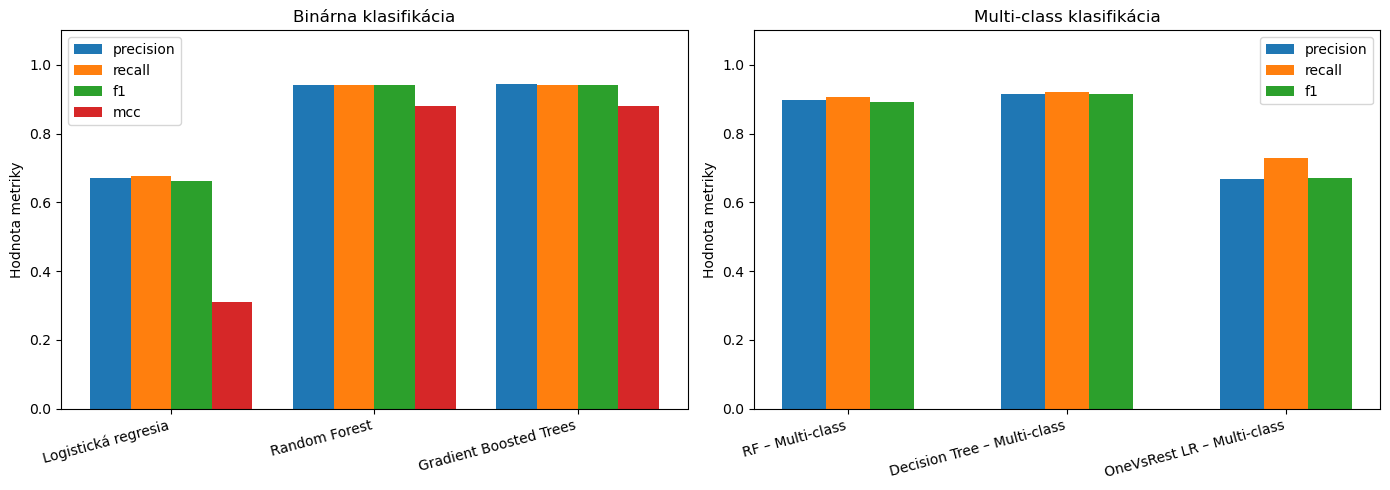

In [43]:
# Vizualizácia výsledkov
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binárne modely
metrics_bin = ["precision", "recall", "f1", "mcc"]
x = np.arange(len(results_bin_df))
width = 0.2
for i, m in enumerate(metrics_bin):
    axes[0].bar(x + i*width, results_bin_df[m], width, label=m)
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(results_bin_df["model"], rotation=15, ha="right")
axes[0].set_ylim(0, 1.1)
axes[0].set_title("Binárna klasifikácia")
axes[0].legend()
axes[0].set_ylabel("Hodnota metriky")

# Multi-class modely
metrics_mc = ["precision", "recall", "f1"]
x2 = np.arange(len(results_mc_df))
for i, m in enumerate(metrics_mc):
    axes[1].bar(x2 + i*width, results_mc_df[m], width, label=m)
axes[1].set_xticks(x2 + width)
axes[1].set_xticklabels(results_mc_df["model"], rotation=15, ha="right")
axes[1].set_ylim(0, 1.1)
axes[1].set_title("Multi-class klasifikácia")
axes[1].legend()
axes[1].set_ylabel("Hodnota metriky")

plt.tight_layout()
plt.savefig("porovnanie_modelov.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# Ukončenie Spark session
spark.stop()
print("Spark session ukončená.")